In [6]:
import psycopg2

connection = psycopg2.connect(
    dbname="Heatflation", 
    user="postgres", 
    password="TITI@2020")

In [7]:
# Creating database courier, command it to fetch list of tables and display them
cursor = connection.cursor()


cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'public';
""")


tables = cursor.fetchall()
print("Here are your tables:")
for table in tables:
    print(f"- {table[0]}")

Here are your tables:
- cpi
- food_prices
- ndvi
- rainfall
- v1_combined_raw_base
- v2_real_prices
- v1_join
- v2_join
- v3_base
- v4_trace_pipeline
- v5_trace_pipeline
- v6_trace_pipeline
- v7_heatflation_model
- fin_heat


In [8]:
import pandas as pd

# Selecting data and loading. confirm first 5 rows
query = "SELECT * FROM fin_heat;"

df = pd.read_sql_query(query, connection)

df.head()

C:\Users\USER\anaconda3\AnacondaPath9\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,state,year,month,current_real_price,log_real_price,current_vim_anomaly,current_rfh_anomaly,vim_1m_ago,vim_2m_ago,vim_3m_ago,vim_4m_ago,rfh_1m_ago,rfh_2m_ago,rfh_3m_ago,rfh_4m_ago
0,kaduna,2013,12,46.69,3.843530,-0.0089,0.08,-0.0130,-0.0056,0.0013,0.0026,-0.83,-35.58,-38.45,-34.75
1,kaduna,2014,1,44.58,3.797285,0.0009,0.32,-0.0089,-0.0130,-0.0056,0.0013,0.08,-0.83,-35.58,-38.45
2,kaduna,2014,2,38.92,3.661508,0.0068,0.03,0.0009,-0.0089,-0.0130,-0.0056,0.32,0.08,-0.83,-35.58
3,kaduna,2014,7,26.58,3.280159,0.0018,-72.33,0.0217,0.0334,0.0236,0.0115,-5.99,4.97,33.53,10.28
4,kaduna,2014,9,24.21,3.186766,-0.0109,-11.17,-0.0118,0.0018,0.0217,0.0334,-6.35,-72.33,-5.99,4.97


In [9]:
list(df.columns)

['state',
 'year',
 'month',
 'current_real_price',
 'log_real_price',
 'current_vim_anomaly',
 'current_rfh_anomaly',
 'vim_1m_ago',
 'vim_2m_ago',
 'vim_3m_ago',
 'vim_4m_ago',
 'rfh_1m_ago',
 'rfh_2m_ago',
 'rfh_3m_ago',
 'rfh_4m_ago']

In [10]:
#  checking and calculating correlations
analysis_cols = [
    'log_real_price',
    'current_vim_anomaly', 'vim_1m_ago', 'vim_2m_ago', 'vim_3m_ago', 'vim_4m_ago',
    'current_rfh_anomaly', 'rfh_1m_ago', 'rfh_2m_ago', 'rfh_3m_ago', 'rfh_4m_ago'
]

correlation_matrix = df[analysis_cols].corr()

correlation_matrix[['log_real_price']]

,log_real_price
log_real_price,1.000000
current_vim_anomaly,-0.137990
vim_1m_ago,-0.201449
vim_2m_ago,-0.236743
vim_3m_ago,-0.213066
vim_4m_ago,-0.168313
current_rfh_anomaly,-0.046157
rfh_1m_ago,-0.034380
rfh_2m_ago,0.005895
rfh_3m_ago,-0.019660


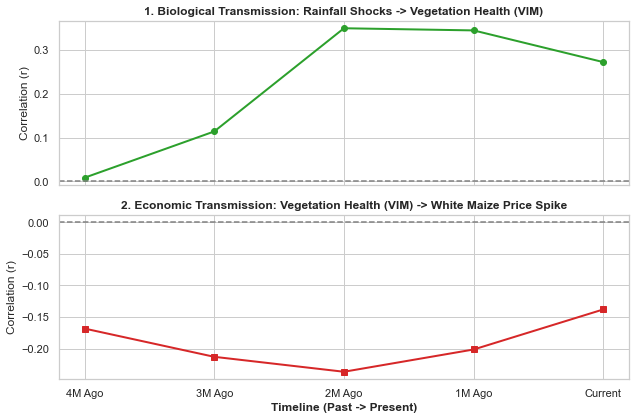

In [19]:
# DEPICTING BIOLOGICAL AND ECONOMIC LAGS

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

timeline = ['4M Ago', '3M Ago', '2M Ago', '1M Ago', 'Current']

# 1. Biological Lag: Past Rainfall vs. Current Crop Health
bio_corrs = [
    df['rfh_4m_ago'].corr(df['current_vim_anomaly']),
    df['rfh_3m_ago'].corr(df['current_vim_anomaly']),
    df['rfh_2m_ago'].corr(df['current_vim_anomaly']),
    df['rfh_1m_ago'].corr(df['current_vim_anomaly']),
    df['current_rfh_anomaly'].corr(df['current_vim_anomaly'])
]

# 2. Economic Lag: Past Crop Health vs. Current Price
econ_corrs = [
    df['vim_4m_ago'].corr(df['log_real_price']),
    df['vim_3m_ago'].corr(df['log_real_price']),
    df['vim_2m_ago'].corr(df['log_real_price']),
    df['vim_1m_ago'].corr(df['log_real_price']),
    df['current_vim_anomaly'].corr(df['log_real_price'])
]

# Plot Biological Lag
axes[0].plot(timeline, bio_corrs, marker='o', color='#2ca02c', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title("1. Biological Transmission: Rainfall Shocks -> Vegetation Health (VIM)", fontweight='bold')
axes[0].set_ylabel("Correlation (r)")

# Plot Economic Lag
axes[1].plot(timeline, econ_corrs, marker='s', color='#d62728', linewidth=2)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title("2. Economic Transmission: Vegetation Health (VIM) -> White Maize Price Spike", fontweight='bold')
axes[1].set_ylabel("Correlation (r)")
axes[1].set_xlabel("Timeline (Past -> Present)", fontweight='bold')

plt.tight_layout()
plt.savefig('lag.png', dpi=300, bbox_inches='tight')
plt.show()

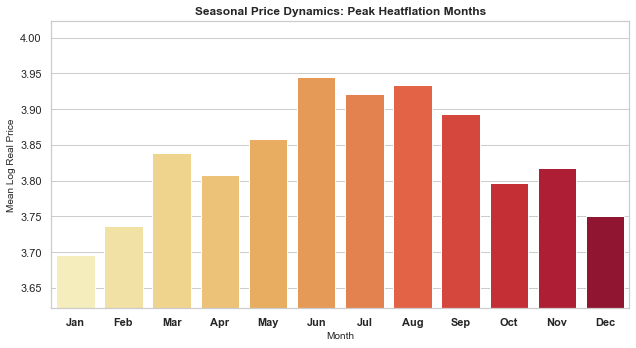

In [20]:
# MONTHS PRONE TO HEATFLATION

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Calculate monthly average log real price
monthly_avg = df.groupby('month')['log_real_price'].mean().reset_index()

# Plot single bar chart
ax = sns.barplot(data=monthly_avg, x='month', y='log_real_price', palette="YlOrRd")

# Map integer month values to calendar month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(12), labels=month_names, fontweight='bold')

# Adjust y-axis range to highlight seasonal variance
min_val = monthly_avg['log_real_price'].min() * 0.98
max_val = monthly_avg['log_real_price'].max() * 1.02
plt.ylim(min_val, max_val)

# Formatting
plt.title("Seasonal Price Dynamics: Peak Heatflation Months", fontsize=12, fontweight='bold')
plt.xlabel("Month", fontsize=10)
plt.ylabel("Mean Log Real Price", fontsize=10)

plt.tight_layout()
plt.savefig('months.png', dpi=300, bbox_inches='tight')
plt.show()

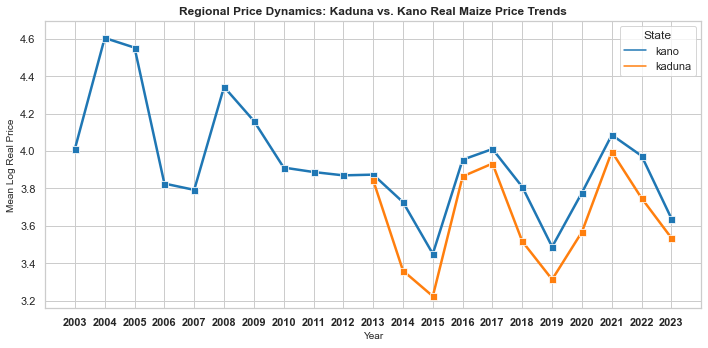

In [21]:
# KADUNA VS KANO PRICE DYNAMICS

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Calculate yearly average log real price by state
state_yearly = df.groupby(['year', 'state'])['log_real_price'].mean().reset_index()

# Plot line chart comparing Kaduna and Kano price trajectories
sns.lineplot(
    data=state_yearly, 
    x='year', 
    y='log_real_price', 
    hue='state', 
    marker='s', 
    linewidth=2.5, 
    markersize=7,
    palette=['#1f77b4', '#ff7f0e']  # Blue for Kaduna, Orange for Kano
)

# Adjust y-axis range to emphasize cross-state price divergence
min_val = state_yearly['log_real_price'].min() * 0.98
max_val = state_yearly['log_real_price'].max() * 1.02
plt.ylim(min_val, max_val)

# Format x-axis with integer year labels
plt.xticks(state_yearly['year'].unique(), rotation=0, fontweight='bold')

# Formatting
plt.title("Regional Price Dynamics: Kaduna vs. Kano Real Maize Price Trends", fontsize=12, fontweight='bold')
plt.xlabel("Year", fontsize=10)
plt.ylabel("Mean Log Real Price", fontsize=10)
plt.legend(title="State", frameon=True)

plt.tight_layout()
plt.savefig('state.png', dpi=300, bbox_inches='tight')
plt.show()

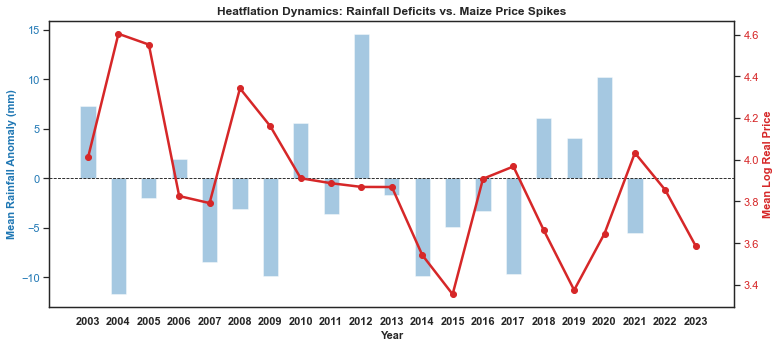

In [22]:
# YEARS WITH HEATFLATION SPIKES

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(11, 5))

# Calculate yearly averages for rainfall anomaly and log real price
yearly_data = df.groupby('year').agg({
    'current_rfh_anomaly': 'mean',
    'log_real_price': 'mean'
}).reset_index()

# 1. BAR CHART: Rainfall Anomalies (Left Axis)
color_rfh = '#1f77b4'
ax1.set_xlabel('Year', fontweight='bold', fontsize=11)
ax1.set_ylabel('Mean Rainfall Anomaly (mm)', color=color_rfh, fontweight='bold', fontsize=11)
ax1.bar(yearly_data['year'], yearly_data['current_rfh_anomaly'], color=color_rfh, alpha=0.4, width=0.5, label='Rainfall Anomaly')
ax1.tick_params(axis='y', labelcolor=color_rfh)
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)

# 2. LINE CHART: Log Real Price Trajectory (Right Axis)
ax2 = ax1.twinx()
color_price = '#d62728'
ax2.set_ylabel('Mean Log Real Price', color=color_price, fontweight='bold', fontsize=11)
ax2.plot(yearly_data['year'], yearly_data['log_real_price'], color=color_price, marker='o', linewidth=2.5, label='Log Real Price')
ax2.tick_params(axis='y', labelcolor=color_price)

# Formatting
plt.title("Heatflation Dynamics: Rainfall Deficits vs. Maize Price Spikes", fontsize=12, fontweight='bold')
ax1.set_xticks(yearly_data['year'].unique())
ax1.set_xticklabels(yearly_data['year'].unique(), rotation=0, fontweight='bold')

plt.tight_layout()
plt.savefig('years.png', dpi=300, bbox_inches='tight')
plt.show()

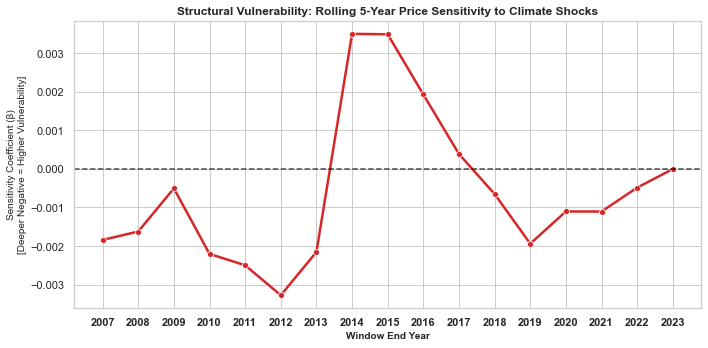

In [23]:
# STRUCTURAL VULNERABILITY: ROLLING SENSITIVITY MODEL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

years = sorted(df['year'].unique())
rolling_slopes = []

# Calculate 5-year rolling sensitivity coefficient (Price elasticity to Rainfall)
for i in range(len(years) - 4):
    window_years = years[i:i+5]
    sub = df[df['year'].isin(window_years)]
    
    if len(sub) > 5 and sub['current_rfh_anomaly'].std() > 0:
        slope, _ = np.polyfit(sub['current_rfh_anomaly'], sub['log_real_price'], 1)
        rolling_slopes.append({'end_year': window_years[-1], 'slope': slope})

slope_df = pd.DataFrame(rolling_slopes)

# Plot rolling sensitivity trajectory
sns.lineplot(data=slope_df, x='end_year', y='slope', marker='o', color='#d62728', linewidth=2.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)

# Formatting
plt.title("Structural Vulnerability: Rolling 5-Year Price Sensitivity to Climate Shocks", fontsize=12, fontweight='bold')
plt.xlabel("Window End Year", fontsize=10, fontweight='bold')
plt.ylabel("Sensitivity Coefficient (β)\n[Deeper Negative = Higher Vulnerability]", fontsize=10)
plt.xticks(slope_df['end_year'].unique(), rotation=0, fontweight='bold')

plt.tight_layout()
plt.savefig('sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()